# Doom training (ViZDoom)
---

# Introduction
We trained DRL agents for two scenarios (personas) in Doom:
- Defend the center (attacker persona)
- Deadly Corridor (survivor persona)

With two different algorithms Proximal Policy Optimization (PPO) and Advantage Actor Critic (A2C). So in total, we performed 4 experiments:
- PPO on Defend the center
- A2C on Defend the center
- PPO on Deadly corridor
- A2C on Deadly corridor

These experiments were performed in the <a href="https://vizdoom.farama.org/">ViZDoom</a>. A Doom Environment for Python for purposes of training AI agents, it is maintained Farama Foundation, which also maintain the Gymnasium library (a fork of OpenAI's gym)

In this notebook, we examine the results from the logs, from reward functions to loss. As well as doing a visual comparison of the models in the two scenarios.

Note: All graphs and gifs can be found in the `resources/` directory.

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from tensorboard.backend.event_processing import event_accumulator

# Defend the center performance analysis

In this section we will look at the model performance of PPO and A2C in the "Defend the Center" scenario. The scenario is created such that DoomGuy (Playable Character) is in the center of the room and enemies are spawning around. Some enemies are charging towards him as melee and others are standing still and shooting at DoomGuy. The goal of the scenario is stay alive as long as possible and eliminate as many enemies, therefore I shaped the rewards for a killer persona. The reward function for both models are the same which can be also found `envs/doom_env.py`:

```
    def step(self, action):
        ...
            kill_delta = kills - self.last_kills
            KILL_REWARD = 2.0 # double points
            reward += kill_delta * KILL_REWARD
            self.last_kills = kills

            # Death penalty
            if truncated:
                reward -= 10.0
        ...
```

This is simple reward function that rewards kills and penalizes deaths. In this section, we show the graphs of the performance of both models.

## Analysis of PPO during "Defend the Center"

Proximal Policy Optimization model was trained for 125,000 timesteps with the following parameters:
      
      HParams:
         -`policy="CnnPolicy"`
         -`learning_rate=2.5e-4`
         -`n_steps=4096`
         -`batch_size=2048`
         -`gamma=0.99`
         -`gae_lambda=0.95`
         -`clip_range=0.1`
         -`ent_coef=0.01`
         -`vf_coef=0.5`
         -`max_grad_norm=0.5`

The following graphs show total reward as metric, training loss of ppo and mean reward over timesteps during training. Analysis of the graph show no change in performance currently in total rewards. However training losses indicate that the model would eventually converge to match the optimal policy of the reward function. Moreover, mean reward is increasing over timesteps. This clearly indicates PPO is very good, it just needs a longer time to train. We also show the visual performance in the evaluation.


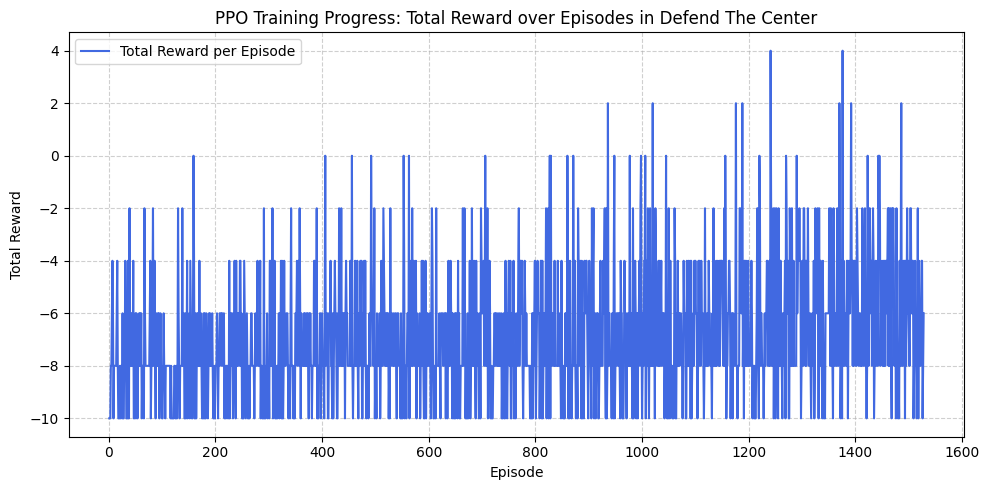

In [5]:
PPO_DEFEND_LOG_FILE = "../logs/ppo_defend_center/ppo_defend_center_episodes_v1_125000.csv"

df = pd.read_csv(PPO_DEFEND_LOG_FILE)

episode_col = "episode" if "episode" in df.columns else df.columns[0]
reward_col = "total_reward" if "total_reward" in df.columns else df.columns[-1]

# plot reward over episodes
plt.figure(figsize=(10, 5))
plt.plot(df[episode_col], df[reward_col], label="Total Reward per Episode", color='royalblue')
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("PPO Training Progress: Total Reward over Episodes in Defend The Center")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

Available scalar tags: ['rollout/ep_len_mean', 'rollout/ep_rew_mean', 'time/fps', 'train/approx_kl', 'train/clip_fraction', 'train/clip_range', 'train/entropy_loss', 'train/explained_variance', 'train/learning_rate', 'train/loss', 'train/policy_gradient_loss', 'train/value_loss']


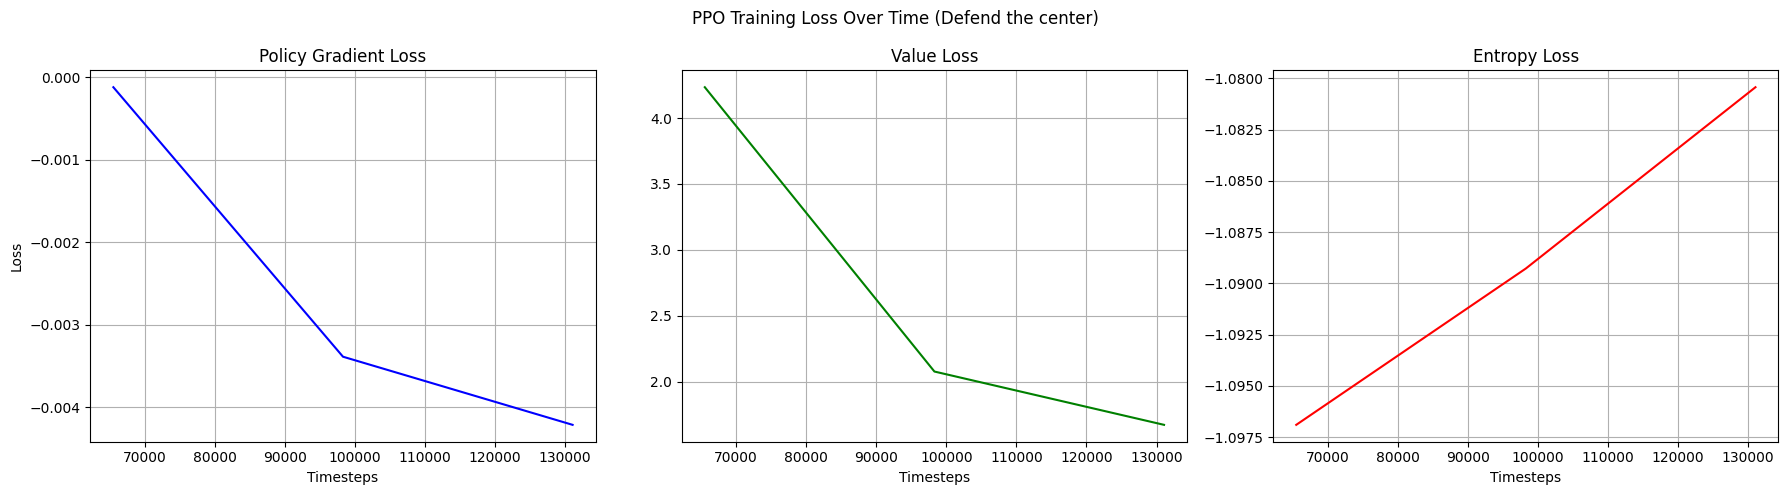

In [10]:
# Path to your specific TensorBoard log directory
log_dir = "../logs/ppo_defend_center/ppo_defend_center_2/"
event_file = next(f for f in os.listdir(log_dir) if f.startswith("events"))
event_path = os.path.join(log_dir, event_file)

# Load the event data
ea = event_accumulator.EventAccumulator(event_path)
ea.Reload()

# print("Available scalar tags:", ea.Tags()["scalars"])

policy_loss = ea.Scalars('train/policy_gradient_loss')
value_loss = ea.Scalars('train/value_loss')
entropy_loss = ea.Scalars('train/entropy_loss')

# Convert to lists
steps = [x.step for x in policy_loss]  # assume all have same steps
policy_vals = [x.value for x in policy_loss]
value_vals = [x.value for x in value_loss]
entropy_vals = [x.value for x in entropy_loss]

# Plot in 1x3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(steps, policy_vals, color='blue')
axes[0].set_title('Policy Gradient Loss')
axes[0].set_xlabel('Timesteps')
axes[0].set_ylabel('Loss')
axes[0].grid(True)

axes[1].plot(steps, value_vals, color='green')
axes[1].set_title('Value Loss')
axes[1].set_xlabel('Timesteps')
axes[1].grid(True)

axes[2].plot(steps, entropy_vals, color='red')
axes[2].set_title('Entropy Loss')
axes[2].set_xlabel('Timesteps')
axes[2].grid(True)

fig.suptitle("PPO Training Loss Over Time (Defend the center)")

plt.tight_layout()
plt.show()

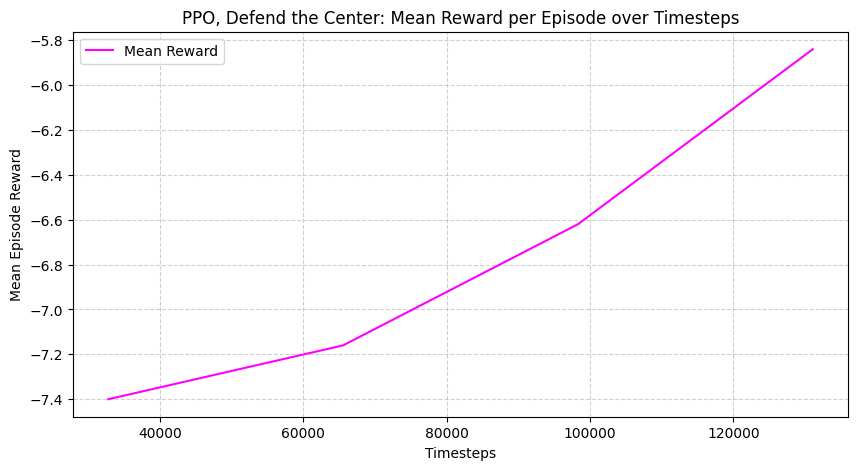

In [14]:
# Example: plot the reward mean per iteration
mean_rew = ea.Scalars("rollout/ep_rew_mean")

steps = [s.step for s in mean_rew]
values = [s.value for s in mean_rew]

plt.figure(figsize=(10, 5))
plt.plot(steps, values, label="Mean Reward", color="magenta")
plt.xlabel("Timesteps")
plt.ylabel("Mean Episode Reward")
plt.title("PPO, Defend the Center: Mean Reward per Episode over Timesteps")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()

## Analysis of A2C during "Defend the Center"

Advantage Actor Critic model was trained for 125,000 timesteps with the following parameters:
      
      HParams:
         -`policy="CnnPolicy"`
         -`learning_rate=2.5e-4`
         -`n_steps=4096`
         -`batch_size=2048`
         -`gamma=0.99`
         -`gae_lambda=0.95`
         -`ent_coef=0.01`
         -`vf_coef=0.5`
         -`max_grad_norm=0.5`

The following graph shows the total rewards per episode. They seem to fluctuate a lot, however visually in the evaluation simulations, they perform equally to PPO.

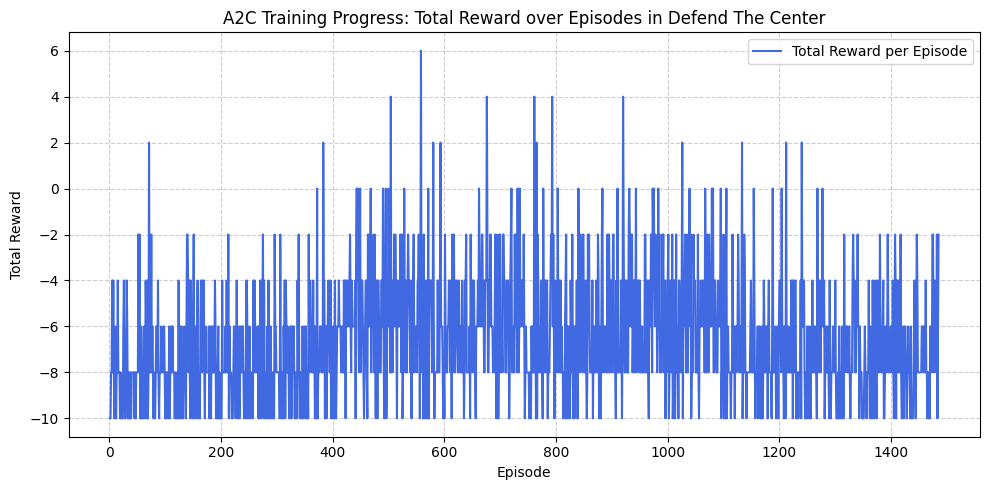

In [15]:
A2C_DEFEND_LOG_FILE = "../logs/a2c_defend_center/a2c_defend_center_episodes_v1_125000.csv"

df = pd.read_csv(A2C_DEFEND_LOG_FILE)

episode_col = "episode" if "episode" in df.columns else df.columns[0]
reward_col = "total_reward" if "total_reward" in df.columns else df.columns[-1]

# plot reward over episodes
plt.figure(figsize=(10, 5))
plt.plot(df[episode_col], df[reward_col], label="Total Reward per Episode", color='royalblue')
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("A2C Training Progress: Total Reward over Episodes in Defend The Center")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

# Deadly Corridor performance analysis

In this scenario, it is bit more complicated because the idea is that there is a corridor and DoomGuy is at the start and he has to get the armor piece at the end of corridor. There are enemies on the side and he has to move through the corridor and survive. Therefore, for the reward shaping, we made "survivor" persona. The reward function for both models are identical which can be also found `envs/doom_env.py`:

```
    def step(self, action):
        ...
        movement_reward = self.game.make_action(actions[action], 4) # points for literally doing any action
        ...
            camera_reward = -abs(camera_angle - 180) / 180 # normalizing and giving it a negative value
            camera_reward = camera_reward * 0.3
            reward = (
                movement_reward
                + hitcount_delta * 210
                + ammo_delta * 5
                - damage_taken_delta * 10
                + camera_reward
            )
        ...
```

This reward function first takes in the fact if doomguy has performed any of the seven available actions during the episode and reward it for doing an action. Then we give the agent a negative reward because we don't want the agent to run into walls, so we take camera angle relative to the floor plane and calculate how far away it is from the normal. Then we penalize if it too much to the side. We also reward doomguy for hitting as many enemies relative to the episodes, how he conserves ammo and penalize how much damage he takes. Based on these rewards, the total reward is summed.

## Analysis of PPO during "Deadly Corridor"

Proximal Policy Optimization model was trained for 125,000 timesteps with the following parameters:
      
      HParams:
         -`policy="CnnPolicy"`
         -`learning_rate=2.5e-4`
         -`n_steps=4096`
         -`batch_size=2048`
         -`gamma=0.99`
         -`gae_lambda=0.95`
         -`clip_range=0.1`
         -`ent_coef=0.01`
         -`vf_coef=0.5`
         -`max_grad_norm=0.5`

In the graphs below, we can observe that the total reward varies a lot (noisy) and it barely hits positive values. Moreover, we can observe in the loss, that is not on the path to convergence. Moreover it is shown that mean reward fell down a bit but it is slowly increasing. Recommendation would be train with a larger amount of timesteps.


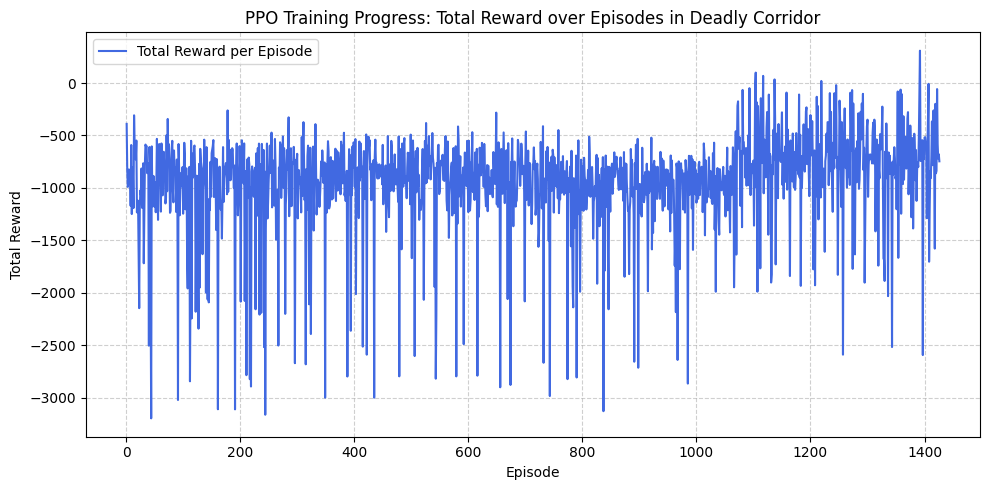

In [23]:
PPO_DEADLY_LOG_FILE = "../logs/ppo_deadly_corridor/ppo_deadly_corridor_episodes_v2.csv"

df = pd.read_csv(PPO_DEADLY_LOG_FILE)

episode_col = "episode" if "episode" in df.columns else df.columns[0]
reward_col = "total_reward" if "total_reward" in df.columns else df.columns[-1]

# plot reward over episodes
plt.figure(figsize=(10, 5))
plt.plot(df[episode_col], df[reward_col], label="Total Reward per Episode", color='royalblue')
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("PPO Training Progress: Total Reward over Episodes in Deadly Corridor")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

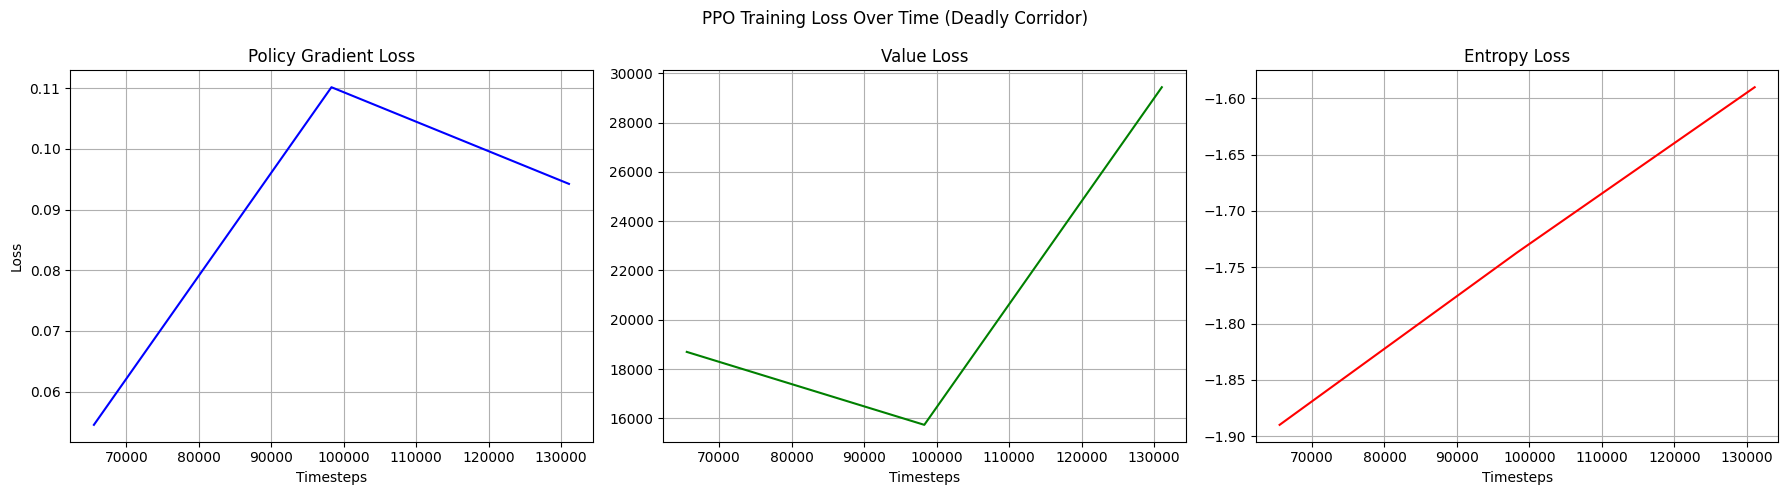

In [29]:
# Path to your specific TensorBoard log directory
log_dir = "../logs/ppo_deadly_corridor/ppo_deadly_corridor_125000_1/"
event_file = next(f for f in os.listdir(log_dir) if f.startswith("events"))
event_path = os.path.join(log_dir, event_file)

# Load the event data
ea = event_accumulator.EventAccumulator(event_path)
ea.Reload()

# print("Available scalar tags:", ea.Tags()["scalars"])

policy_loss = ea.Scalars('train/policy_gradient_loss')
value_loss = ea.Scalars('train/value_loss')
entropy_loss = ea.Scalars('train/entropy_loss')

# Convert to lists
steps = [x.step for x in policy_loss]  # assume all have same steps
policy_vals = [x.value for x in policy_loss]
value_vals = [x.value for x in value_loss]
entropy_vals = [x.value for x in entropy_loss]

# Plot in 1x3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(steps, policy_vals, color='blue')
axes[0].set_title('Policy Gradient Loss')
axes[0].set_xlabel('Timesteps')
axes[0].set_ylabel('Loss')
axes[0].grid(True)

axes[1].plot(steps, value_vals, color='green')
axes[1].set_title('Value Loss')
axes[1].set_xlabel('Timesteps')
axes[1].grid(True)

axes[2].plot(steps, entropy_vals, color='red')
axes[2].set_title('Entropy Loss')
axes[2].set_xlabel('Timesteps')
axes[2].grid(True)

fig.suptitle("PPO Training Loss Over Time (Deadly Corridor)")

plt.tight_layout()
plt.show()

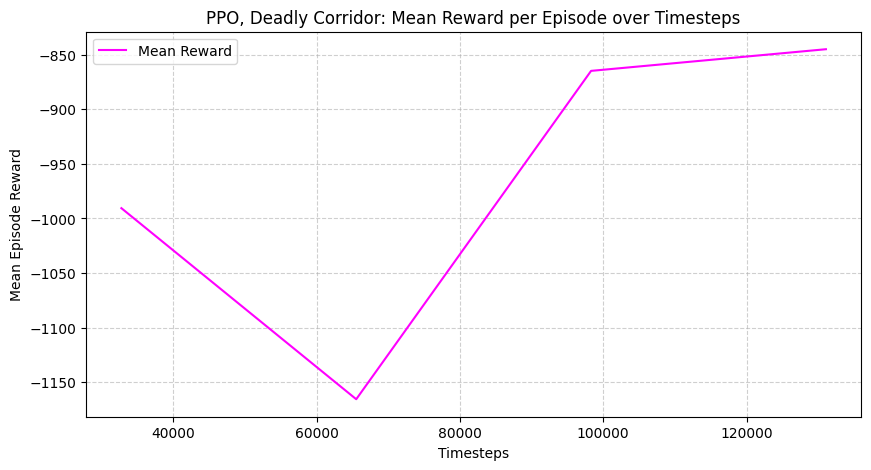

In [31]:
# Example: plot the reward mean per iteration
mean_rew = ea.Scalars("rollout/ep_rew_mean")

steps = [s.step for s in mean_rew]
values = [s.value for s in mean_rew]

plt.figure(figsize=(10, 5))
plt.plot(steps, values, label="Mean Reward", color="magenta")
plt.xlabel("Timesteps")
plt.ylabel("Mean Episode Reward")
plt.title("PPO, Deadly Corridor: Mean Reward per Episode over Timesteps")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()

## Analysis of A2C during "Deadly Corridor"

Advantage Actor Critic model was trained for 125,000 timesteps with the following parameters:
      
      HParams:
         -`policy="CnnPolicy"`
         -`learning_rate=2.5e-4`
         -`n_steps=4096`
         -`batch_size=2048`
         -`gamma=0.99`
         -`gae_lambda=0.95`
         -`ent_coef=0.01`
         -`vf_coef=0.5`
         -`max_grad_norm=0.5`

The following graph shows the total rewards per episode. They seem to fluctuate a lot, however visually in the evaluation simulations, they perform better than PPO. This is also evident in the graph after around 800 episodes, reward function values are greater than 0. Perhaps an explanation is that A2C converged quicker in this scenario.


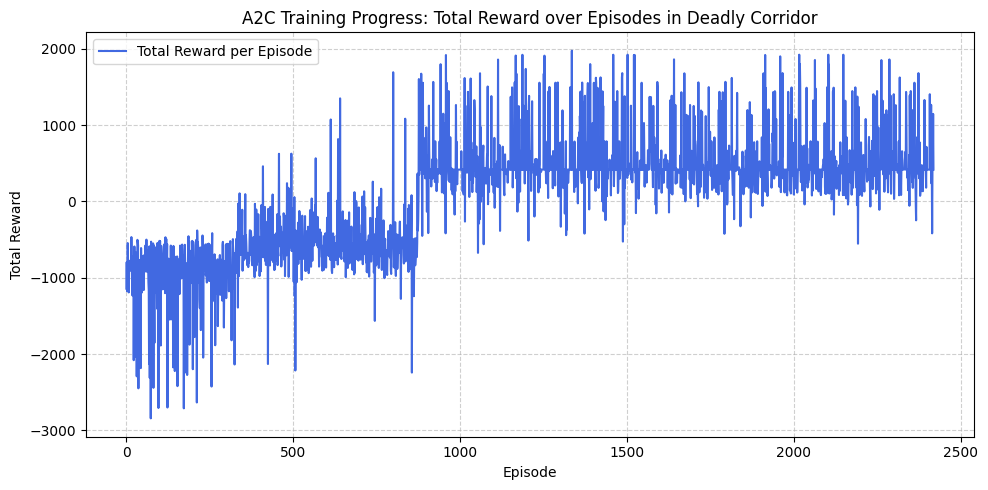

In [26]:
A2C_DEADLY_LOG_FILE = "../logs/a2c_deadly_corridor/a2c_deadly_corridor_episodes_v1_125000.csv"

df = pd.read_csv(A2C_DEADLY_LOG_FILE)

episode_col = "episode" if "episode" in df.columns else df.columns[0]
reward_col = "total_reward" if "total_reward" in df.columns else df.columns[-1]

# plot reward over episodes
plt.figure(figsize=(10, 5))
plt.plot(df[episode_col], df[reward_col], label="Total Reward per Episode", color='royalblue')
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("A2C Training Progress: Total Reward over Episodes in Deadly Corridor")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

# Visual Comparison of Models in different scenarios

## 'Defend The Center' Scenario

From the gifs, below we can see that PPO and A2C share similar performances, however it seems that PPO has a higher hitcount.
<center>
    <img style="width: 400px;" src="resources/gifs/ppo_defend_the_center.gif"></img>

    PPO: Defend the Center
</center>
<center>
    <img style="width: 400px;" src="resources/gifs/a2c_defend_the_center.gif"></img>

    A2C: Defend the Center
</center>

## 'Deadly Corridor' Scenario

We can observe that both models seem to complete their objective. However it seems like A2C tends to complete the objective faster by not looking around. So technically it is completing the objective but fails to mimic human players in the sense of playing a game.

<center>
    <img style="width: 400px;" src="resources/gifs/ppo_deadly_corridor.gif"></img>

    PPO: Deadly Corridor
</center>
<center>
    <img style="width: 400px;" src="resources/gifs/a2c_deadly_corridor.gif"></img>

    A2C: Deadly Corridor
</center>